# NB_P2_05 - MCD-rPPG Multi-Camera Multi-Modal Preprocessing

**Extends NB_P2_04** to process all three camera views and extract three video-derived biosignals:
- `rppg_signal` - remote photoplethysmography (POS algorithm, ROI-averaged RGB)
- `rbcg_signal` - remote ballistocardiography (head displacement at cardiac frequency)
- `rresp_signal` - remote respiration (nose-tip vertical displacement at respiratory frequency)

All three signals are extracted in a **single video pass** per recording.

**Cameras processed:** USBVideo, FullHDwebcam, IriunWebcam
**HDF5 path:** `subject/{id}/recordings/{state}/{camera}/`
**FPS and resolution:** derived from actual video headers, not hardcoded

---

### Signal physiology

| Signal | Source | Frequency band | Ground truth |
|--------|--------|----------------|--------------|
| rPPG | Skin colour change (blood volume) | 0.7 - 4 Hz | PPG wristband |
| rBCG | Head recoil from cardiac mechanical impulse | 0.7 - 5 Hz | ECG R-peaks (HRV) |
| rRESP | Head nodding with respiratory effort | 0.1-0.5 Hz | `respiratory` col in db.csv|

## 1. Enviroment Setup

In [1]:
import subprocess, sys

packages = [
    "neurokit2",
    "mediapipe",
    "h5py",
    "opencv-python",
    "scipy",
    "numpy",
    "pandas",
    "matplotlib"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages confirmed.")

All packages confirmed.


## 2. Imports and Paths

In [2]:
import os, warnings, cv2, h5py, urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from scipy.signal import butter, filtfilt
from collections import Counter
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f0f0f", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444444", "axes.labelcolor": "#e0e0e0",
    "xtick.color": "#e0e0e0", "ytick.color": "#e0e0e0",
    "text.color": "#e0e0e0", "grid.color": "#2a2a3e",
    "grid.linestyle": "--", "grid.alpha": 0.5, "figure.dpi": 110,
})

# Paths 
MCD_DIR = "F:/MCD-rppg/MCD_rPPG_dataset"
OUTPUT_DIR = "E:/QualityPhys"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASET_NAME = "mcd_rppg_multicam"
HDF5_PATH = os.path.join(OUTPUT_DIR, "mcd_rppg_multicam.h5")
KNOWLEDGE_DISTILLATION_ROLE = "student_only"

# rPPG: frontal only
RPPG_CAMERA = "FullHDwebcam"
# rBCG/rRESP: frontal is best, but side views add value
# since head displacement signals are camera-angle-independent
# (the J-wave recoil is visible from any angle, just at different
# projected magnitudes). 
RBCG_RRESP_CAMERAS = ["FullHDwebcam", "USBVideo", "IriunWebcam"]
CAMERAS  = RBCG_RRESP_CAMERAS
STATES = ["before", "after"]
STATE_NAMES = {"before": "rest", "after": "post_exercise"}

print(f"Dataset path : {MCD_DIR}")
print(f"Output HDF5 : {HDF5_PATH}")
print(f"rPPG Camera : {RPPG_CAMERA}")
print(f"rBCG/rRESP Cameras: {RBCG_RRESP_CAMERAS}")
print(f"States : {STATES}")
print()
print("Signal parameters will be set in Cell 4 after data exploration.")

Dataset path : F:/MCD-rppg/MCD_rPPG_dataset
Output HDF5 : E:/QualityPhys\mcd_rppg_multicam.h5
rPPG Camera : FullHDwebcam
rBCG/rRESP Cameras: ['FullHDwebcam', 'USBVideo', 'IriunWebcam']
States : ['before', 'after']

Signal parameters will be set in Cell 4 after data exploration.


## 3. Data Exploration

In [3]:
db_path = os.path.join(MCD_DIR, "db.csv")
df_db = pd.read_csv(db_path)

print("=" * 60)
print("1. db.csv OVERVIEW")
print("=" * 60)
print(f"Shape: {df_db.shape[0]} rows x {df_db.shape[1]} columns")
print(f"Cameras in dataset : {sorted(df_db['camera'].unique())}")
print(f"States in dataset : {sorted(df_db['step'].unique())}")
print(f"Subjects : {df_db['patient_id'].nunique()}")
print()
print("All columns:")
for col in df_db.columns:
    print(f"{col:<30} dtype={str(df_db[col].dtype):<10} unique={df_db[col].nunique():<6} sample={df_db[col].dropna().iloc[0]}")

print()
print("=" * 60)
print("2. FPS PER CAMERA (reading from actual video headers)")
print("=" * 60)

camera_fps = {}
camera_res = {}
camera_nframes = {}

for cam in CAMERAS:
    # Find one example vide for this camera from db.csv
    cam_rows = df_db[df_db["camera"] == cam]
    if len(cam_rows) == 0:
        print(f"{cam}: NOT FOUND in db.csv")
        continue
    sample_rel = cam_rows.iloc[0]["video"]
    sample_path = os.path.join(MCD_DIR, sample_rel)

    if not os.path.exists(sample_path):
        print(f"{cam}: file not found at {sample_path}")
        continue

    cap = cv2.VideoCapture(sample_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    camera_fps[cam] = fps
    camera_res[cam] = (width, height)
    camera_nframes[cam] = n_frames
    duration_s = n_frames / fps if fps > 0 else 0 
    print(f"{cam:<16} FPS={fps:.2f}  resolution={width}x{height} frames={n_frames}  duration={duration_s:.1f}s")

print()
print("=" * 60)
print("3. ECG FORMAT (read from JSON)")
print("=" * 60)

ecg_sample_rel = df_db[df_db["ecg"].notna()].iloc[0]["ecg"]
ecg_sample_path = os.path.join(MCD_DIR, ecg_sample_rel)

with open(ecg_sample_path, "r") as file:
    ecg_json = json.load(file)

ecg_fs_actual = float(ecg_json["frequency"])
leads_found = [lead["title"] for lead in ecg_json["data"]]
n_samples_ecg = len(ecg_json["data"][0]["values"])
ecg_duration = n_samples_ecg / ecg_fs_actual

print(f"File : {ecg_sample_rel}")
print(f"Keys : {list(ecg_json.keys())}")
print(f"Frequency : {ecg_fs_actual} Hz")
print(f"Leads : {leads_found}")
print(f"Samples : {n_samples_ecg} -> {ecg_duration:.1f} s")
print(f"Value range : {min(ecg_json['data'][0]['values']):.4f} to {max(ecg_json['data'][0]['values']):.4f} (mV)")

print()
print("=" * 60)
print("4. PPG FORMAT (read from .PW file)")
print("=" * 60)

ppg_sample_rel = df_db[df_db["ppg"].notna()].iloc[0]["ppg"]
ppg_sample_path = os.path.join(MCD_DIR, ppg_sample_rel)
df_ppg_sample = pd.read_csv(ppg_sample_path, sep=r"\s+", header=None, dtype=str)

ppg_raw_sample = df_ppg_sample.iloc[:, 0].astype(np.float32).values
datetime_str = df_ppg_sample.iloc[:, 1] + " " + df_ppg_sample.iloc[:, 2]
ts_dt = pd.to_datetime(datetime_str, format="%Y-%m-%d %H:%M:%S.%f")
ts_s = (ts_dt - ts_dt.iloc[0]).dt.total_seconds().values
ppg_fs_actual = 1.0 / np.diff(ts_s).mean()
ppg_duration = ts_s[-1]

print(f"File : {ppg_sample_rel}")
print(f"Rows : {len(df_ppg_sample)}")
print(f"Columns : int_amplitude + date + time (3 whitespace-separated)")
print(f"Est. fs  : {ppg_fs_actual:.2f} Hz")
print(f"Duration : {ppg_duration:.1f} s")
print(f"Value range : {ppg_raw_sample.min():.0f} - {ppg_raw_sample.max():.0f} (integer ADC)")

print()
print("=" * 60)
print("5. BIOMARKER COLUMNS")
print("=" * 60)
# Show stress range to confirm scale
print(f"stress range : {df_db['stress'].min():.2f} – {df_db['stress'].max():.2f} (NOT full PSM-25, likely 1–10 ordinal scale)")
print(f"sex values : {sorted(df_db['sex'].dropna().unique())} (string, not numeric)")
print(f"hemoglobin : {df_db['hemoglobin'].min():.1f} – {df_db['hemoglobin'].max():.1f} g/dL")

print()
print("=" * 60)
print("SUMMARY - values to use as config")
print("=" * 60)
for cam, fps in camera_fps.items():
    print(f"{cam} FPS = {fps:.2f}")
print(f"ECG_FS = {ecg_fs_actual:.0f} Hz")
print(f"ECG_DURATION = {ecg_duration:.0f} s (diagnostic strip)")
print(f"PPG_FS ≈ {ppg_fs_actual:.0f} Hz (estimated from timestamps)")

1. db.csv OVERVIEW
Shape: 3600 rows x 25 columns
Cameras in dataset : ['FullHDwebcam', 'IriunWebcam', 'USBVideo']
States in dataset : ['after', 'before']
Subjects : 600

All columns:
patient_id                     dtype=int64      unique=600    sample=1020
weight                         dtype=float64    unique=71     sample=55.0
height                         dtype=float64    unique=46     sample=170.0
bmi                            dtype=float64    unique=436    sample=19.031141868512112
age                            dtype=float64    unique=40     sample=23.0
sex                            dtype=object     unique=2      sample=F
upper_ap                       dtype=float64    unique=97     sample=113.0
lower_ap                       dtype=float64    unique=53     sample=78.0
saturation                     dtype=float64    unique=11     sample=98.0
temperature                    dtype=float64    unique=12     sample=36.6
hemoglobin                     dtype=float64    unique=77     sa

## 4. Configuration

In [4]:
# All signal parameters below come from actual data inspection

# Camera FPS
CAMERA_FPS = camera_fps 

#rPPG: frontal only
RPPG_CAMERAS = ["FullHDwebcam"]

# rBCG/rRESP: frontal is best, but side views add value
# since head displacement signals are camera-angle-independent
# (the J-wave recoil is visible from any angle, just at different
# projected magnitudes). Include all three for rBCG/rRESP,
# frontal only for rPPG.
RBCG_RRESP_CAMERAS = ["FullHDwebcam", "USBVideo", "IriunWebcam"]

# ECG 
ECG_FS = ecg_fs_actual # 500.0 Hz 
ECG_DURATION_S = ecg_duration # ~30 s - diagnostic strip, not full session
ECG_LEAD = "II" # best QRS morphology for Pan-Tompkins R-peak detection

# PPG
PPG_FS = round(ppg_fs_actual) # ~100 Hz estimated from inter-sample timestamps


# Bandpass limits (physiology-driven, no camera-specific)
# rPPG: cardiac blood volume pulse
RPPG_BP_LOW, RPPG_BP_HIGH = 0.7, 3.5 
# ECG: preserve QRS complex (fast components up to 40 Hz) + remove baseline wander
ECG_BP_LOW, ECG_BP_HIGH = 0.5, 40.0
# PPG: systolic peaks, remove motion artefacts above 8 Hz
PPG_BP_LOW, PPG_BP_HIGH = 0.5, 8.0 
# rBCG: head recoil from cardiac mechanical impulse 
RBCG_BP_LOW, RBCG_BP_HIGH = 0.7, 5.0 
# rRESP: respiratory effort - 6-30 breaths/min = 0.1-0.5 Hz
RRESP_BP_LOW , RRESP_BP_HIGH = 0.1, 0.5

# Quality Thresholds
RPPG_SQI_THRESHOLD = 0.4
ECG_SQI_THRESHOLD = 0.5
NO_FACE_THRESHOLD = 20.0 # % of frames - skip if more than this

# HR/physiological limits
HR_MIN = 40
HR_MAX = 200

# Biomarker tiers
# Confirmed from db.csv column names 
BIOMARKER_TIERS = {
    # Tier 1 — derivable from rPPG/rBCG with solid literature support
    "respiratory_rate" : "tier_1_confident",

    # Tier 2 — may be derivable, limited literature, high uncertainty
    "systolic_bp" : "tier_2_experimental",  # PAT-based, requires calibration
    "diastolic_bp" : "tier_2_experimental",
    "spo2"  : "tier_2_experimental",
    "arterial_stiffness" : "tier_2_experimental",  # PWV, m/s
    "stress_psm25" : "tier_2_experimental",  # ordinal scale 1–7.52, not PSM-25

    # Tier 3 — conditioning inputs (model receives, does not predict)
    "age" : "tier_3_conditioning",
    "sex" : "tier_3_conditioning",   # string 'F'/'M'
    "bmi" : "tier_3_conditioning",

    # Tier 4 — not feasible via rPPG/rBCG, store for completeness only
    "temperature" : "tier_4_not_feasible",
    "glycated_hb" : "tier_4_not_feasible",
    "cholesterol" : "tier_4_not_feasible",
    "hemoglobin"  : "tier_4_not_feasible",
}

# Physiological plausibility ranges 
BIOMARKER_RANGES = {
    "systolic_bp" : (70, 220), # mmHg
    "diastolic_bp" : (40, 130), # mmHg
    "spo2" : (85, 100), # %
    "respiratory_rate" : (6, 40), # breaths/min
    "arterial_stiffness" : (3, 18), # m/s (PWV) 
    "stress_psm25" : (0, 10), # confirmed max=7.52 in this dataset
    "age" : (18, 90),
    "bmi" : (16, 60), # kg/m²
    "temperature" : (35, 40), # °C
    "glycated_hb"  : (4, 15), # %
    "cholesterol" : (2, 12), # mmol/L
    "hemoglobin" : (7, 20), # g/dL
}

# Facial ROI landmark indices (MediaPipe face mesh) 
FOREHEAD_LM = [10, 338, 297, 332, 284, 251, 389, 356, 454,
               323, 361, 288, 397, 365, 379, 378, 400, 377,
               152, 148, 176, 149, 150, 136, 172, 58, 132,
               93, 234, 127, 162, 21, 54, 103, 67, 109]
LEFT_CHEEK_LM  = [234, 227, 116, 123, 147, 213, 192, 214, 210,
                  211, 206, 203, 36, 101, 119, 229, 228]
RIGHT_CHEEK_LM = [454, 447, 345, 352, 376, 433, 416, 434, 430,
                  431, 426, 423, 266, 330, 348, 449, 448]
ROI_CONFIGS = {
    "forehead" : FOREHEAD_LM,
    "left_cheek" : LEFT_CHEEK_LM,
    "right_cheek": RIGHT_CHEEK_LM,
}

# rBCG landmark: nose tip (LM 1) — best single point for detecting
# subtle anterior-posterior head displacement from cardiac impulse.
# Forehead centroid used as second anchor to reduce rotational artefact.
RBCG_NOSE_LM = 1
RBCG_FOREHEAD_LMs = [10, 151, 9, 8]   # central forehead landmarks

# rRESP landmark: nose tip vertical (y) displacement tracks respiratory
# head nodding. Chin (LM 152) used as cross-check.
RRESP_NOSE_LM = 1
RRESP_CHIN_LM = 152

# Column mapping from db.csv to internal names 
COLUMN_MAP = {
    "patient_id" : "subject_id",
    "step" : "state",
    "upper_ap" : "systolic_bp",
    "lower_ap" : "diastolic_bp",
    "saturation" : "spo2",
    "glycated_hemoglobin" : "glycated_hb",
    "respiratory" : "respiratory_rate",
    "rigidity" : "arterial_stiffness",
    "stress" : "stress_psm25",
    # temperature, cholesterol, age, sex, bmi, hemoglobin already match
}

print("Configuration loaded from data exploration.")
print()
print("Camera FPS (from video headers):")
for cam, fps in CAMERA_FPS.items():
    print(f"{cam:<16} {fps:.2f} Hz")
print(f"ECG_FS = {ECG_FS:.0f} Hz (from JSON frequency field)")
print(f"ECG_DURATION_S = {ECG_DURATION_S:.0f} s (diagnostic strip only)")
print(f"PPG_FS ≈ {PPG_FS} Hz (from .PW timestamps)")
print()
tier_counts = Counter(BIOMARKER_TIERS.values())
for tier, count in sorted(tier_counts.items()):
    print(f"{tier:<30}: {count} biomarkers")

Configuration loaded from data exploration.

Camera FPS (from video headers):
FullHDwebcam     29.90 Hz
USBVideo         30.00 Hz
IriunWebcam      24.00 Hz
ECG_FS = 500 Hz (from JSON frequency field)
ECG_DURATION_S = 30 s (diagnostic strip only)
PPG_FS ≈ 100 Hz (from .PW timestamps)

tier_1_confident              : 1 biomarkers
tier_2_experimental           : 5 biomarkers
tier_3_conditioning           : 3 biomarkers
tier_4_not_feasible           : 4 biomarkers


## 4. Build Recording Inventory

In [5]:
def build_inventory(mcd_dir: str, cameras: list, states: list) -> pd.DataFrame:
    """
    Build per-recording inventory for all cameras.

    db.csv has one row per (subjext x state x camera) - 3600 rows total.
    We keep all camera rows for the selected states.
    ECG and PPG files are shared across cameras for the same subject/state.

    HDF5 key: subjects/{id}/recordings/{state}/{camera}/
    """
    db_path = os.path.join(mcd_dir, "db.csv")
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"db.csv not found at {db_path}")

    df_db = pd.read_csv(db_path)

    # Filter to selected cameras and states
    df_filt = df_db[(df_db["camera"].isin(cameras)) & (df_db["step"].isin(states))].copy().reset_index(drop=True)

    print(f"Rows after filter: {len(df_filt)}")
    print(f"Expected: 600 subjects x {len(states)} states x {len(cameras)} cameras = {600 * len(states) * len(cameras)}")

    # Rename to internal names
    df_filt = df_filt.rename(columns={key: value for key, value in COLUMN_MAP.items() if key in df_filt.columns})

    records = []
    for _, row in df_filt.iterrows():
        subject_id = int(row["subject_id"])
        state = row["state"]
        camera = row["camera"]

        video_path = os.path.join(mcd_dir, row["video"])
        ecg_path = os.path.join(mcd_dir, row["ecg"])
        ppg_path = os.path.join(mcd_dir, row["ppg"])

        has_video = os.path.exists(video_path)
        has_ecg = os.path.exists(ecg_path)
        has_ppg = os.path.exists(ppg_path)

        biomarkers = {}
        for biomarker in BIOMARKER_TIERS.keys():
            raw = row.get(biomarker, np.nan)
            try:
                biomarkers[biomarker] = float(raw)
            except (ValueError, TypeError):
                biomarkers[biomarker] = raw # "F"/"M" for sex

        record = {
            "subject_id" : subject_id,
            "state" : state,
            "state_name" : STATE_NAMES.get(state, state),
            "camera" : camera,
            "fps" : CAMERA_FPS.get(camera, 30.0),
            "video_path" : video_path if has_video else None,
            "ecg_path" : ecg_path if has_ecg else None,
            "ppg_path" : ppg_path if has_ppg else None,
            "complete" : has_video,
            "has_ecg" : has_ecg,
            "has_ppg" : has_ppg,
        }
        record.update(biomarkers)
        records.append(record)

    df = pd.DataFrame(records).sort_values(["subject_id", "state", "camera"]).reset_index(drop=True)

    return df

df_inventory = build_inventory(MCD_DIR, CAMERAS, STATES)

print(f"Total recordings : {len(df_inventory)}")
print(f"Complete (video) : {df_inventory['complete'].sum()}")
print(f"With ECG file : {df_inventory['has_ecg'].sum()}")
print(f"With PPG file : {df_inventory['has_ppg'].sum()}")
print()
print("Per camera:")
for cam in CAMERAS:
    sub = df_inventory[df_inventory["camera"] == cam]
    print(f"{cam:<16} total={len(sub)} complete={sub['complete'].sum()} fps={sub['fps'].iloc[0]:.2f}")
print()
print("Biomarker coverage:")
# Check on one camera slice to avoid triple-counting
df_one_cam = df_inventory[df_inventory["camera"] == CAMERAS[0]]
for biomarker in BIOMARKER_TIERS.keys():
    if biomarker in df_one_cam.columns:
        n_valid = df_one_cam[biomarker].notna().sum()
        tier = BIOMARKER_TIERS[biomarker]
        print(f"  {biomarker:<25} {n_valid:>4}/{len(df_one_cam)} [{tier}]")
    else:
        print(f"  {biomarker:<25} COLUMN NOT FOUND")

Rows after filter: 3600
Expected: 600 subjects x 2 states x 3 cameras = 3600
Total recordings : 3600
Complete (video) : 3600
With ECG file : 3600
With PPG file : 3600

Per camera:
FullHDwebcam     total=1200 complete=1200 fps=29.90
USBVideo         total=1200 complete=1200 fps=30.00
IriunWebcam      total=1200 complete=1200 fps=24.00

Biomarker coverage:
  respiratory_rate          1200/1200 [tier_1_confident]
  systolic_bp               1200/1200 [tier_2_experimental]
  diastolic_bp              1200/1200 [tier_2_experimental]
  spo2                      1200/1200 [tier_2_experimental]
  arterial_stiffness        1200/1200 [tier_2_experimental]
  stress_psm25              1200/1200 [tier_2_experimental]
  age                       1200/1200 [tier_3_conditioning]
  sex                       1200/1200 [tier_3_conditioning]
  bmi                       1200/1200 [tier_3_conditioning]
  temperature               1200/1200 [tier_4_not_feasible]
  glycated_hb               1200/1200 [tier_4_

## 6. Signal loaders


In [6]:
def load_ecg_signal(ecg_path: str) -> dict:
    """
    Load MCD-rPPG ECG from JSON.

    Confirmed format
        frequency : 500 Hz
        data : list of lead dicts - {"title" : "II", "values" : [mV floats]}
        Duration : ~30 s (diagnostic strip, Not full session)

    Lead II prefered - tallest R-waves, best for Pan-Tompkins detection.
    """
    if not ecg_path or not os.path.exists(ecg_path):
        return None

    try:
        with open(ecg_path, "r") as file:
            ecg_json = json.load(file)
    except (json.JSONDecodeError, OSError) as error:
        print(f"WARNING: Corrupted ECG JSON at {ecg_path} - {error}")
        print(f"Falling back to PPG-only mode for this recording.")
        return None
        
    ecg_fs = float(ecg_json.get("frequency", ECG_FS))
    if not (200.0 < ecg_fs < 1000.0):
        print(f"WARNING: ECG frequency{ecg_fs} Hz unexpected - check JSON")

    leads = {lead["title"]: np.array(lead["values"], dtype=np.float32) for lead in ecg_json["data"]}

    lead_used = ECG_LEAD if ECG_LEAD in leads else "I" if "I" in leads else list(leads.keys())[0]
    if lead_used != ECG_LEAD:
        print(f"WARNING: Lead {ECG_LEAD} not found, using {lead_used}")

    ecg_raw = leads[lead_used]
    timestamps = np.arange(len(ecg_raw)) / ecg_fs

    return {
        "ecg_raw" : ecg_raw,
        "timestamps" : timestamps,
        "ecg_fs" : ecg_fs,
        "lead" : lead_used,
        "all_leads" : list(leads.keys()),
    }


def load_ppg_signal(ppg_path: str) -> dict:
    """
    Load MCD-rPPG PPG from .PW format.

    Confirmed format
        integer_amplitude YYY-MM-DD HH:MM:S.ffffff
    Two whitespace-separated columns. Fs estimated from timestamps.
    Duration: ~180 s - full session (use for hr_continuous).
    """
    if not ppg_path or not os.path.exists(ppg_path):
        return None

    try:
        df = pd.read_csv(ppg_path, sep=r"\s+", header=None, dtype=str)
        ppg_raw = df.iloc[:, 0].astype(np.float32).values
        datetime_str = df.iloc[:, 1] + " " + df.iloc[:, 2]
        ts_dt = pd.to_datetime(datetime_str, format="mixed")
        timestamps = (ts_dt - ts_dt.iloc[0]).dt.total_seconds().values.astype(np.float64)
    except Exception as error:
        print(f"WARNING: Corrupted PPG file at {ppg_path} - {error}")
        print(f"Falling back to ECG-only mode for this recording.")
        return None

    dt_s = np.diff(timestamps).mean() if len(timestamps) > 1 else 1.0 / PPG_FS
    ppg_fs = 1.0 / dt_s if dt_s > 0 else PPG_FS
    if not (50.0 < ppg_fs < 200.0):
        print(f"WARNING: PPG fs={ppg_fs:.1f} Hz unexpected - check .PW file")

    return {
        "ppg_raw" : ppg_raw,
        "timestamps" : timestamps,
        "ppg_fs" : float(ppg_fs),
    }

print("Signal loaders defined.")

Signal loaders defined.


## 7. MediaPipe setup and single-pass video feature extraction

All three signals (rPPG, rBCG, rRESP) are extracted in one pass per video.

In [7]:
MODEL_PATH = "./face_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face landmarker model...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        MODEL_PATH
    )
    print("Downloaded.")
else:
    print("Face landmarker model already present.")

def get_roi_mask(landmarks, frame_shape: tuple, lm_indices: list) -> np.ndarray:
    """Binary polygon mask for one ROI."""
    h, w = frame_shape[:2]
    pts = np.array([[int(landmarks[i].x * w), int(landmarks[i].y * h)] for i in lm_indices], dtype=np.int32)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def extract_all_video_signals(video_path : str, roi_configs : dict, max_frames: int = None) -> dict:
    """
    Single-pass extraction of rPPG, rBCG, and rRESP features from video.

    Returns per-frame arrays:
        roi_rbg : [T, n_rois, 3] - spatially-averaged RGB per ROI (rPPG input)
        nose_x/y : [T] - nose-tip pixel position (rBCG + rRESP input)
        forehead_y : [T] - forehead centroid y (rBCG anchor)
        chin_y : [T] - chin landmark y (rRESP cross-check)
        actual_fps : float - FPS read from this specific video file
        n_frames : int - total frames processed
        no_face_pct : float - % frames where face was not detected

    rBCG physiology: cardiac impulse causes ~0.1-0.5 mm anterior-posterior head displacement.
    In frontal video this manifests as subtle vertical (y) movement of nose tip relative to 
    the forehead anchor. Bandpassed at cardiac frequency to isolate the BCG waveform.

    rRESP physiology: breathing causes slow head nodding and chest rise. Vertical displacement
    of noise tip at respiratory frequency (0.1-0.5 Hz) reliably tracks respiration rate in 
    controlled settings.
    """
    cap = cv2.VideoCapture(video_path)
    actual_fps = cap.get(cv2.CAP_PROP_FPS)

    roi_names = list(roi_configs.keys())
    roi_sigs = {name: [] for name in roi_names}
    nose_x_px = [] # nose tip x pixel
    nose_y_px = [] # nose tip y pixel
    fhead_y_px = [] # forehead centroid y pixel
    chin_y_px = [] # chin y pixel

    n_frames = 0
    no_face_ct = 0

    base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and n_frames >= max_frames:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            h, w = rgb.shape[:2]
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            ts_ms = int((n_frames / actual_fps) * 1000)
            result = landmarker.detect_for_video(mp_img, ts_ms)

            if result.face_landmarks:
                lm = result.face_landmarks[0]

                # rPPG: spatially-averaged RGB per ROI
                for name, indices in roi_configs.items():
                    mask = get_roi_mask(lm, rgb.shape, indices)
                    if mask.sum() > 0: 
                        r = rgb[:, :, 0][mask == 1].mean()
                        g = rgb[:, :, 1][mask == 1].mean()
                        b = rgb[:, :, 2][mask == 1].mean()
                        roi_sigs[name].append(np.array([r, g, b], dtype=np.float32))
                    else:
                        fallback = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                        roi_sigs[name].append(fallback)

                # rBCG + rRESP: landmark pixel positions
                # Nose tip
                nose = lm[RBCG_NOSE_LM]
                nose_x_px.append(nose.x * w)
                nose_y_px.append(nose.y * h)

                # Forehead centroid (mean y of forehead landmarks)
                fhead_ys = [lm[i].y * h for i in RBCG_FOREHEAD_LMs]
                fhead_y_px.append(np.mean(fhead_ys))

                # Chin
                chin_y_px.append(lm[RRESP_CHIN_LM].y * h)
            else:
                # No face detected - forward-fill all signals
                no_face_ct += 1 
                for name in roi_names:
                    fallback = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                    roi_sigs[name].append(fallback)
                for lst in [nose_x_px, nose_y_px, fhead_y_px, chin_y_px]:
                    lst.append(lst[-1] if lst else 0.0)
            n_frames += 1

    cap.release()

    # Convert to arrays
    return {
        "roi_rgb" : np.stack([np.array(roi_sigs[n]) for n in roi_names], axis=1).astype(np.float32), # [T, n_rois, 3]
        "nose_x" : np.array(nose_x_px, dtype=np.float32),
        "nose_y" : np.array(nose_y_px, dtype=np.float32),
        "forehead_y" : np.array(fhead_y_px, dtype=np.float32),
        "chin_y" : np.array(chin_y_px, dtype=np.float32),
        "actual_fps" : actual_fps,
        "n_frames" : n_frames,
        "no_face_pct" : round(100 * no_face_ct / max(n_frames, 1), 1),
    }

print("Video extraction function defined.")

Face landmarker model already present.
Video extraction function defined.


## 8. Signal processing

In [8]:
def bandpass_filter(signal: np.ndarray, fs: float, low: float, high: float, order: int = 2) -> np.ndarray:
    """
    Zero-phase Butterworth bandpass filter. 
    Returns zeros if signal too short.
    """
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    min_len = 3 * max(len(a), len(b))
    if len(signal) <= min_len:
        print(f"WARNING: signal too short for filter (len={len(signal)}, min={min_len}_ - returning zeros")
        return np.zeros_like(signal, dtype=np.float32)
    return filtfilt(b, a, signal).astype(np.float32)


def resample_to_fps(signal: np.ndarray, original_fs: float, target_fps: float) -> np.ndarray:
    """Resample physiological signal to video FPS via linear interpolation."""
    n_orig = len(signal)
    n_target = int(n_orig * target_fps / original_fs)
    return np.interp(np.linspace(0, 1, n_target), np.linspace(0,1, n_orig), signal).astype(np.float32)


def extract_rppg(roi_rgb: np.ndarray, fps:float) -> np.ndarray:
    """
    POS algorithm averaged across ROIs.
        roi_rgb : [T, n_rois, 3]
    Returns normalised rPPG signal [T]
    """
    P = np.array([[0, 1, -1], [-2, 1, 1]], dtype=np.float64)
    signals = [] 
    n_rois = roi_rgb.shape[1]

    for r in range(n_rois):
        C = roi_rgb[:, r, :].astype(np.float64) # [T, 3]
        Cn = C / (C.mean(axis=0) + 1e-8)
        S = P @ Cn.T
        h = S[0] + (S[0].std() / (S[1].std() + 1e-8)) * S[1]
        signals.append(h)

    combined = np.mean(signals, axis=0)
    filtered = bandpass_filter(combined, fps, RPPG_BP_LOW, RPPG_BP_HIGH)
    mu, sigma = filtered.mean(), filtered.std() + 1e-8
    return ((filtered - mu) / sigma).astype(np.float32)


def extract_rbcg(nose_y: np.ndarray, forehead_y: np.ndarray, fps: float) -> np.ndarray:
    """
    Remote BCG from head displacement at cardiac frequency.

    Method: relative vertical displacement of nose tip vs forehead centroid.
    Using relative (nose - forehead) rather thatn absolute nose position
    removes slow drift and whole-head translation, isolating the differential
    mechanical impulse (BCG J-wave).
    """
    relative = (nose_y - forehead_y).astype(np.float64)
    # Remove mean (DC offset)
    relative -= relative.mean()
    filtered = bandpass_filter(relative, fps, RBCG_BP_LOW, RBCG_BP_HIGH)
    mu, sigma = filtered.mean(), filtered.std() + 1e-8
    return ((filtered - mu) / sigma).astype(np.float32)


def extract_rresp(nose_y: np.ndarray, chin_y: np.ndarray, fps: float) -> np.ndarray:
    """
    Remote respiration from head nodding at respiratory frequency.

    Method: absolute nose_y displacement bandpassed at respiratory frequency.
    Chin_y is averaged in to reduce rotational head movement artefact.
    Both landmarks move together with breathing but in opposite ways
    for head nod vs rotation - averaging suppresses rotation.

    Ground truth: respiratory_rate column in db.csv (breaths/min).
    """
    combined = ((nose_y + chin_y) / 2.0).astype(np.float64)
    combined -= combined.mean()
    filtered = bandpass_filter(combined, fps, RRESP_BP_LOW, RRESP_BP_HIGH)
    mu, sigma = filtered.mean(), filtered.std() + 1e-8
    return ((filtered - mu) / sigma).astype(np.float32)


def detect_ecg_peaks(ecg_raw: np.ndarray, ecg_fs: float) -> tuple:
    """R-peak detection via NeuroKit2. Returns (peak_indices, rr_ms, hr_mean, ecg_filtered)."""
    ecg_filtered = bandpass_filter(ecg_raw, ecg_fs, ECG_BP_LOW, ECG_BP_HIGH)
    ecg_clean = nk.ecg_clean(ecg_filtered, sampling_rate=int(ecg_fs))
    peak_dict, _ = nk.ecg_peaks(ecg_clean, sampling_rate=int(ecg_fs))
    peak_indices = np.where(peak_dict["ECG_R_Peaks"] == 1)[0]

    if len(peak_indices) < 3:
        return peak_indices, np.array([]), float("nan"), ecg_filtered

    rr_ms = np.diff(peak_indices) / ecg_fs * 1000.0
    hr_mean = float(60000.0 / rr_ms.mean())
    return peak_indices, rr_ms, hr_mean, ecg_filtered


def detect_ppg_peaks(ppg_raw: np.ndarray, ppg_fs: float) -> tuple:
    """Systolic peak detection from PPG. Returns (peak_indices, rr_ms, hr_mean)."""
    ppg_filtered = bandpass_filter(ppg_raw, ppg_fs, PPG_BP_LOW, PPG_BP_HIGH)
    ppg_clean = nk.ppg_clean(ppg_filtered, sampling_rate=int(ppg_fs))
    peak_dict, _ = nk.ppg_peaks(ppg_clean, sampling_rate=int(ppg_fs))
    peak_indices = np.where(peak_dict["PPG_Peaks"] == 1)[0]

    if len(peak_indices) <3:
        return peak_indices, np.array([]), float("nan")

    rr_ms = np.diff(peak_indices) / ppg_fs * 1000.0
    hr_mean = float(60000.0 / rr_ms.mean())
    return peak_indices, rr_ms, hr_mean


def compute_hrv_features(rr_ms: np.ndarray) -> dict:
    """Time domain HRV from RR intervals."""
    nan_r = {key: float("nan") for key in ["mean_rr_ms", "sdnn_ms", "rmssd_ms", 
                                          "pnn50_pct", "hr_mean_bpm", "hr_min_bpm", "hr_max_bpm"]}
    if len(rr_ms) < 3:
        return nan_r
    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr_clean) < 3:
        return nan_r
    diffs = np.diff(rr_clean)
    return {
        "mean_rr_ms" : float(rr_clean.mean()),
        "sdnn_ms" : float(rr_clean.std()),
        "rmssd_ms" : float(np.sqrt(np.mean(diffs ** 2))),
        "pnn50_pct" : float((np.abs(diffs) > 50).mean() * 100),
        "hr_mean_bpm" : float(60000.0 / rr_clean.mean()),
        "hr_min_bpm" : float(60000.0 / rr_clean.max()),
        "hr_max_bpm" : float(60000.0 / rr_clean.min())
    }

def build_hr_continuous(peak_indices: np.ndarray, rr_ms: np.ndarray, source_fs: float, n_frames: int, target_fps: float) -> np.ndarray:
    """
    Build continuous HR array at video frame rate.
    Works for both ECG peaks (source_fs=ECG_FS) and PPG peaks (source_fs=PGS_FS).
    """
    hr_continuous = np.full(n_frames, np.nan, dtype=np.float32)
    if len(peak_indices) < 2 or len(rr_ms) == 0:
        return hr_continuous

    for i, idx in enumerate(peak_indices[:-1]):
        frame_idx = int(idx / source_fs * target_fps)
        if 0 <= frame_idx < n_frames:
            hr_continuous[frame_idx] = 60000.0 / rr_ms[i]

    last_hr = np.nan
    for i in range(n_frames):
        if not np.isnan(hr_continuous[i]):
            last_hr = hr_continuous[i]
        elif not np.isnan(last_hr):
            hr_continuous[i] = last_hr
    return hr_continuous

print("Signal processing functions defined.")

Signal processing functions defined.


## 9. SQI functions

In [9]:
def compute_ecg_sqi(rr_ms: np.ndarray) -> float:
    """ECG SQI - RR interval regularity. Score = 1 - CV."""
    if len(rr_ms) < 3:
        return float("nan")
    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr_clean) < 3:
        return float("nan")
    cv = rr_clean.std() / (rr_clean.mean() + 1e-8)
    return float(1.0 - min(cv, 1.0))



def compute_rppg_sqi(rppg_signal: np.ndarray, hr_bpm: float, fps: float) -> float:
    """rPPG SQI - autocorrelation at expected HR lag."""
    if hr_bpm <= 0 or np.isnan(hr_bpm):
        return float("nan")
    beat_period = int(round(fps * 60.0 / hr_bpm))
    if beat_period >= len(rppg_signal):
        return float("nan")
    s = rppg_signal - rppg_signal.mean()
    denom = np.dot(s, s)
    if denom < 1e-10:
        return 0.0
    numer = np.dot(s[:-beat_period], s[beat_period:])
    return float(max(0.0, min(numer / denom, 1.0)))


def compute_rbcg_sqi(rbcg_signal: np.ndarray, hr_bpm: float, fps: float) -> float:
    """
    rBCG SQI - same autocorrelation method as rPPG SQI.
    BCG should also have periodicity at cardiac rate if signal is clean.
    """
    return compute_rppg_sqi(rbcg_signal, hr_bpm, fps)


def compute_rresp_sqi(rresp_signal: np.ndarray, rr_bpm: float, fps: float) -> float:
    """
    rRESP SQI - autocorrelation at expected respiratory rate lag.
    rr_bpm: respiratory rate in breaths/min.
    Returns nan if ground truth RR not available.
    """
    if np.isnan(rr_bpm) or rr_bpm <= 0:
        return float("nan")
    return compute_rppg_sqi(rresp_signal, rr_bpm, fps)

print("SQI functions defined.")

SQI functions defined.


## 10. Single-recording demo - inspect signals visually

Inspecting: subject 1020, state after, camera FullHDwebcam (29.9 fps)

ECG: 15000 samples at 500.0 Hz = 30.0 s

Extracting 300 frames from video (demo)...
Video: 300 frames at 29.9 fps no_face=0.0%
roi_rgb shape: (300, 3, 3) [T, n_rois, RGB]


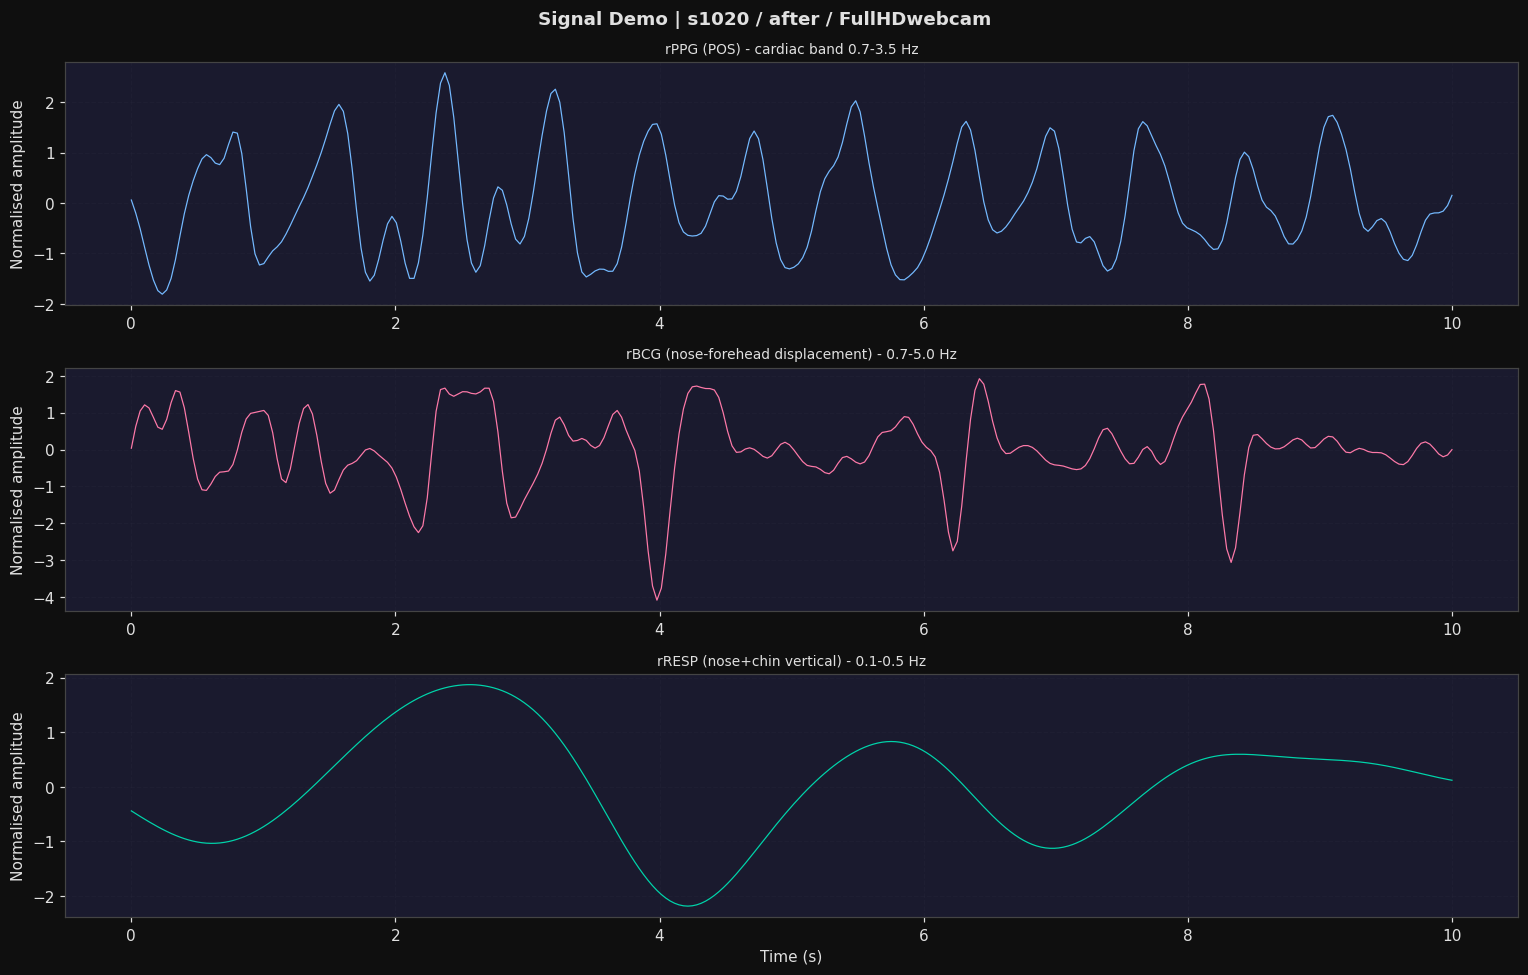

In [10]:
first = df_inventory[df_inventory["complete"]].iloc[0]
demo_fps = first["fps"]
print(f"Inspecting: subject {first.subject_id}, state {first.state}, camera {first.camera} ({demo_fps:.1f} fps)")
print()

ecg_demo = load_ecg_signal(first["ecg_path"])
ppg_demo = load_ppg_signal(first["ppg_path"])

if ecg_demo:
    n = len(ecg_demo["ecg_raw"])
    print(f"ECG: {n} samples at {ecg_demo['ecg_fs']:.1f} Hz = {n/ecg_demo['ecg_fs']:.1f} s")
    
print()
print("Extracting 300 frames from video (demo)...")
vid_data = extract_all_video_signals(first["video_path"], ROI_CONFIGS, max_frames=300)
print(f"Video: {vid_data['n_frames']} frames at {vid_data['actual_fps']:.1f} fps no_face={vid_data['no_face_pct']:.1f}%")
print(f"roi_rgb shape: {vid_data['roi_rgb'].shape} [T, n_rois, RGB]")

# Compute all three signals from demo
rppg_demo = extract_rppg(vid_data["roi_rgb"], vid_data["actual_fps"])
rbcg_demo = extract_rbcg(vid_data["nose_y"], vid_data["forehead_y"], vid_data["actual_fps"])
rresp_demo = extract_rresp(vid_data["nose_y"], vid_data["chin_y"], vid_data["actual_fps"])

# Plot all three signals
T = len(rppg_demo)
t_s = np.arange(T) / vid_data["actual_fps"]

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle(f"Signal Demo | s{first.subject_id} / {first.state} / {first.camera}", fontsize=12, fontweight="bold")

axes[0].plot(t_s, rppg_demo, color="#74b9ff", lw=0.8)
axes[0].set_title(f"rPPG (POS) - cardiac band {RPPG_BP_LOW}-{RPPG_BP_HIGH} Hz", fontsize=9)
axes[0].set_ylabel("Normalised amplitude")

axes[1].plot(t_s, rbcg_demo, color="#fd79a8", lw=0.8)
axes[1].set_title(f"rBCG (nose-forehead displacement) - {RBCG_BP_LOW}-{RBCG_BP_HIGH} Hz", fontsize=9)
axes[1].set_ylabel("Normalised amplitude")

axes[2].plot(t_s, rresp_demo, color="#00d4aa", lw=0.8)
axes[2].set_title(f"rRESP (nose+chin vertical) - {RRESP_BP_LOW}-{RRESP_BP_HIGH} Hz", fontsize=9)
axes[2].set_ylabel("Normalised amplitude")
axes[2].set_xlabel("Time (s)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/demo_signals_s{first.subject_id}_{first.state}_{first.camera}.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 11. Full single-recording pipeline


In [11]:
def process_single_recording(row: pd.Series, max_frames: int = None) -> tuple:
    """
    Full pipeline for one MCD-rPPG recording (one camera view).

    Camera-dependent extraction:
    FullHDwebcam (frontal) -> rPPG + rBCG + rRESP
    USBVideo / IrunWebcam (profile) -> rBCH + rRESP only
        rPPG is zeroed and rPPG SQI gate is skipped for profile cameras.

    Reference strategy:
        ECG (~30 s, 500 Hz) -> HRV (RMSSD, SDNN, pNN50)
        PPG (~180 s, ~100 Hz) -> hr_continuous + reference_signal
        reference_type = "ECG_hrv_PPG_continuous"

    Returns (result_dict, reason_str). result_dict is None if skipped.
    """
    subject_id = int(row["subject_id"])
    state = row["state"]
    camera = row["camera"]
    label = f"s{subject_id:04d}/{state}/{camera}"
    IS_FRONTAL = (camera == RPPG_CAMERA)

    # Step 1: Load ECG and PPG
    ecg_data = load_ecg_signal(row["ecg_path"])
    ppg_data = load_ppg_signal(row["ppg_path"])

    if ecg_data is None and ppg_data is None:
        print(f"SKIP {label}: no reference signal")
        return None, "no_reference_signal"

    # Step 2: ECG -> HRV (30 s window)
    ecg_sqi = float("nan")
    rr_ms = np.array([])
    hr_mean_ecg = float("nan")

    if ecg_data is not None:
        ecg_raw = ecg_data["ecg_raw"]
        ecg_fs = ecg_data["ecg_fs"]

        if len(ecg_raw) / ecg_fs < 10.0:
            print(f"SKIP {label}: ECG too short")
            return None, "ecg_too_short"

        if ecg_raw.max() - ecg_raw.min() < 0.05: # mV scale
            print(f"SKIP {label}: flat ECG")
            return None, "flat_ecg_signal"
        
        _, rr_ms, hr_mean_ecg, _ = detect_ecg_peaks(ecg_raw, ecg_fs)

        if not np.isnan(hr_mean_ecg):
            ecg_sqi = compute_ecg_sqi(rr_ms)
            if ecg_sqi < ECG_SQI_THRESHOLD:
                print(f"SKIP {label}: ECG SQI too low ({ecg_sqi:.3f})")
                return None, f"ecg_sqi_low ({ecg_sqi:.3f})"

    hrv = compute_hrv_features(rr_ms)

    # Step 3: PPG -> hr_continuous
    if ppg_data is None:
        print(f"SKIP {label}: no PPG - cannot build hr_continuous")
        return None, "no_ppg_signal"

    ppg_raw = ppg_data["ppg_raw"]
    ppg_fs = ppg_data["ppg_fs"]

    if ppg_raw.max() - ppg_raw.min() < 1.0:
        print(f"SKIP {label}: flat PPG")
        return None, "flat_ppg_signal"

    ppg_peak_indices, rr_ms_ppg, hr_mean_ppg = detect_ppg_peaks(ppg_raw, ppg_fs)

    if np.isnan(hr_mean_ppg) or hr_mean_ppg < HR_MIN or hr_mean_ppg > HR_MAX:
        print(f"SKIP {label}: implausible PPG HR ({hr_mean_ppg:.1f} BPM)")
        return None, f"implausible_hr ({hr_mean_ppg:.1f} BPM)"

    if not np.isnan(hr_mean_ecg):
        hr_diff = abs(hr_mean_ecg - hr_mean_ppg)
        if hr_diff > 10:
            print(f"SKIP {label}: ECG/PPG HR mismatch (ECG={hr_mean_ecg:.1f} PPG={hr_mean_ppg:.1f} diff={hr_diff:.1f})")
            return None, f"ecg_ppg_hr_mismatch ({hr_diff:.1f} BPM)"
    hr_mean = hr_mean_ppg
    ppg_resampled = resample_to_fps(ppg_raw, ppg_fs, CAMERA_FPS[camera])

    # Step 4: Video - single pass for all signals
    vid = extract_all_video_signals(row["video_path"], ROI_CONFIGS, max_frames=max_frames)
    n_frames = vid["n_frames"]
    no_face = vid["no_face_pct"]
    actual_fps = vid["actual_fps"]

    if no_face > NO_FACE_THRESHOLD:
        print(f"SKIP {label}: too many frames without face ({no_face:.1f}%)")
        return None, f"no_face ({no_face:.1f}%)"

    # rBCG and rRESP extracted for all cameras
    rbcg_signal = extract_rbcg(vid["nose_y"], vid["forehead_y"], actual_fps)
    rresp_signal = extract_rresp(vid["nose_y"], vid["chin_y"], actual_fps)

    # Step 5: rPPG - frontal camera only
    if IS_FRONTAL:
        rppg_signal = extract_rppg(vid["roi_rgb"], actual_fps)
        rppg_sqi = compute_rppg_sqi(rppg_signal, hr_mean, actual_fps)
        if rppg_sqi < RPPG_SQI_THRESHOLD:
            print(f"SKIP {label}: rPPG SQI too low ({rppg_sqi:.3f})")
            return None, f"rppg_sqi_low ({rppg_sqi:.3f})"
    else:
        # Profile camera - rPPG not meaningful, store zeros
        # rBCG/rRESP are still valid at any angle
        rppg_signal = np.zeros(n_frames, dtype=np.float32)
        rppg_sqi = -1.0 # sentinel: not computed for this camera

    # Step 6: Remaining SQI
    rbcg_sqi = compute_rbcg_sqi(rbcg_signal, hr_mean, actual_fps)
    rr_bpm_gt = float(row.get("respiratory_rate", np.nan))
    rresp_sqi = compute_rresp_sqi(rresp_signal, rr_bpm_gt, actual_fps)

    # Step 7: hr_continuous from PPG peaks
    hr_continuous = build_hr_continuous(ppg_peak_indices, rr_ms_ppg, ppg_fs, n_frames, actual_fps)

    # Step 8: Align all signals to shortest common length
    lengths = [
        n_frames,
        len(rppg_signal),
        len(rbcg_signal),
        len(rresp_signal),
        len(hr_continuous),
        len(ppg_resampled),
        vid["roi_rgb"].shape[0],
    ]
    T = min(lengths)

    rppg_signal = rppg_signal[:T]
    rbcg_signal = rbcg_signal[:T]
    rresp_signal = rresp_signal[:T]
    hr_continuous = hr_continuous[:T]
    roi_rgb = vid["roi_rgb"][:T]
    reference_signal = ppg_resampled[:T]

    # Step 9: Biomarkers
    biomarkers = {}
    biomarker_flags = {}
    for bm in BIOMARKER_TIERS.keys():
        raw = row.get(bm, np.nan)
        try:
            value = float(raw)
        except (ValueError, TypeError):
            value = raw # 'F' / 'M'
        biomarkers[bm] = value

        if bm in BIOMARKER_RANGES and isinstance(value, float) and not np.isnan(value):
            low, high = BIOMARKER_RANGES[bm]
            biomarker_flags[f"{bm}_valid"] = (low <= value <= high)
        else:
            biomarker_flags[f"{bm}_valid"] = np.nan

    rr_intervals = rr_ms.astype(np.float32) if len(rr_ms) > 0 else rr_ms_ppg.astype(np.float32)

    print(f"{label} T={T} HR={hr_mean:.1f} ECG_SQI={ecg_sqi:.2f} rPPG={'N/A' if not IS_FRONTAL else f'{rppg_sqi:.2f}'}")
    print(f"rBCG={rbcg_sqi:.3f} rRESP={rresp_sqi:.3f} no_face={no_face:.1f}% fps={actual_fps:.2f}")

    result = {
        # Signals
        "rppg_signal" : rppg_signal,
        "rbcg_signal" : rbcg_signal,
        "rresp_signal" : rresp_signal,
        "roi_rgb" : roi_rgb,
        "reference_signal" : reference_signal,
        "hr_continuous" : hr_continuous,
        "rr_intervals" : rr_intervals,
        # HRV
        "hr_mean" : float(hr_mean),
        "rmssd_ms" : hrv["rmssd_ms"],
        "sdnn_ms" : hrv["sdnn_ms"],
        "pnn50_pct" : hrv["pnn50_pct"],
        # Biomarkers
        **biomarkers,
        **biomarker_flags,
        # Metadata
        "subject_id" : subject_id,
        "activity_id" : state,
        "activity_name" : STATE_NAMES.get(state, state),
        "camera" : camera,
        "is_frontal" : IS_FRONTAL,
        "dataset" : DATASET_NAME,
        "reference_type" : "ECG_hrv_PPG_continuous",
        "n_frames" : T,
        "fps" : actual_fps,
        "ecg_sqi" : float(ecg_sqi) if not np.isnan(ecg_sqi) else -1.0,
        "rppg_sqi" : float(rppg_sqi),
        "rbcg_sqi" : float(rbcg_sqi) if not np.isnan(rbcg_sqi) else -1.0,
        "rresp_sqi" : float(rresp_sqi) if not np.isnan(rresp_sqi) else -1.0,
        "no_face_pct" : float(no_face),
    }
    return result, "ok"

            
# Demo test - 300 frames from first complete recording per camera
print("Running single-recording test (300 frames per camera)...")
print()

for camera in CAMERAS:
    cam_rows = df_inventory[(df_inventory["camera"] == camera) & df_inventory["complete"]]
    if len(cam_rows) == 0:
        print(f"[{camera}] No complete recordings found - skipping.")
        continue

    first = cam_rows.iloc[0]
    is_frontal = (camera == RPPG_CAMERA)
    print(f"[{camera}] subject={first.subject_id} state={first.state} frontal={is_frontal}")
    demo_result, demo_reason = process_single_recording(first, max_frames=300)

    if demo_result is not None:
        print("Signals:")
        for key in ["rppg_signal", "rbcg_signal", "rresp_signal", "roi_rgb", "reference_signal", "hr_continuous", "rr_intervals"]:
            if key in demo_result and hasattr(demo_result[key], "shape"):
                print(f"{key:<22}: {demo_result[key].shape}")

        print("Scalars:")
        for key in ["hr_mean", "rmssd_ms", "sdnn_ms", "pnn50_pct"]:
            value = demo_result.get(key, float("nan"))
            print(f"{key:<22} : {value:.3f}" if not np.isnan(value) else f"{key:<22} : nan" )

        print("Quality:")
        for key in ["ecg_sqi", "rppg_sqi", "rbcg_sqi", "rresp_sqi", "no_face_pct", "fps", "is_frontal"]:
            value = demo_result.get(key, "N/A")
            print(f"{key:<22} : {value:.3f}" if isinstance(value, float) else f"{key:<22} : {value}")

        print("Biomarkers:")
        for bm in BIOMARKER_TIERS.keys():
            value = demo_result.get(bm, np.nan)
            tier = BIOMARKER_TIERS[bm]
            flag = demo_result.get(f"{bm}_valid", "?")
            values = f"{value:>8.2f}" if isinstance(value, (int, float)) else f"{str(value):>8}"
            print(f"{bm:<25} : {values} [{tier}] valid={flag}")
    else:
        print(f"Skipped - {demo_reason}")
    print()

Running single-recording test (300 frames per camera)...

[FullHDwebcam] subject=1020 state=after frontal=True
s1020/after/FullHDwebcam T=300 HR=81.0 ECG_SQI=0.94 rPPG=0.54
rBCG=0.024 rRESP=0.319 no_face=0.0% fps=29.90
Signals:
rppg_signal           : (300,)
rbcg_signal           : (300,)
rresp_signal          : (300,)
roi_rgb               : (300, 3, 3)
reference_signal      : (300,)
hr_continuous         : (300,)
rr_intervals          : (39,)
Scalars:
hr_mean                : 81.042
rmssd_ms               : 41.975
sdnn_ms                : 48.032
pnn50_pct              : 21.053
Quality:
ecg_sqi                : 0.935
rppg_sqi               : 0.535
rbcg_sqi               : 0.024
rresp_sqi              : 0.319
no_face_pct            : 0.000
fps                    : 29.900
is_frontal             : True
Biomarkers:
respiratory_rate          :    19.00 [tier_1_confident] valid=True
systolic_bp               :   113.00 [tier_2_experimental] valid=True
diastolic_bp              :    78.00 [t

## 12. HDF5 write and initialisation

In [12]:
def write_recording_to_hdf5(h5_file: h5py.File, result: dict) -> bool:
    """
    Write one recording to HDF5.
    Path: subjects/{subj}/recordings/{state}/{camera}/

    Camera is included in the path to support multi-camera storage:
        subjects/1020/recordings/after/FullHDwebcam/
        subjects/1020/recordings/after/USBVideo/
        subjects/1020/recordings/after/IrunWebcam/

    Resume-safe: skips if group already exists.
    
    Note on rppg_signal for profile cameras:
    is_frontal=False -> rppg_signal is zeros, rppg_sqi=-1.0
    is_frontal=True -> rppg_signal is real POS output
    """
    subj = f"{result['subject_id']:04d}"
    state = result["activity_id"]
    cam = result["camera"]
    path = f"subjects/{subj}/recordings/{state}/{cam}"

    if path in h5_file:
        return False 

    grp = h5_file.require_group(path)

    # Signal datasets - rppg_signal is zero for profile cameras
    for ds_name in ["rppg_signal", "rbcg_signal", "rresp_signal", "roi_rgb", "reference_signal", "hr_continuous", "rr_intervals"]:
        grp.create_dataset(ds_name, data=result[ds_name], compression="gzip", compression_opts=4)

    # Standard scalar attributes
    std_attrs = {
        "subject_id" : result["subject_id"],
        "activity_id" : result["activity_id"],
        "activity_name" : result["activity_name"],
        "camera" : result["camera"],
        "is_frontal" : result["is_frontal"],
        "dataset" : result["dataset"],
        "reference_type" : result["reference_type"],
        "n_frames" : result["n_frames"],
        "fps" : result["fps"],
        "hr_mean" : result["hr_mean"],
        "rmssd_ms" : result["rmssd_ms"] if not np.isnan(result["rmssd_ms"]) else -1.0,
        "sdnn_ms" : result["sdnn_ms"] if not np.isnan(result["sdnn_ms"]) else -1.0,
        "pnn50_pct" : result["pnn50_pct"] if not np.isnan(result["pnn50_pct"]) else -1.0,
        "ecg_sqi" : result["ecg_sqi"],
        "rppg_sqi" : result["rppg_sqi"],
        "rbcg_sqi" : result["rbcg_sqi"],
        "rresp_sqi" : result["rresp_sqi"],
        "no_face_pct" : result["no_face_pct"],
    }
    for key, value in std_attrs.items():
        grp.attrs[key] = value

    # Biomarker attributes
    for bm, tier in BIOMARKER_TIERS.items():
        value = result.get(bm, np.nan)
        flag = result.get(f"{bm}_valid", np.nan)
        if isinstance(value, str):
            grp.attrs[f"bm_{bm}"] = value
        elif value is None or (isinstance(value, float) and np.isnan(value)):
            grp.attrs[f"bm_{bm}"] = -999.0
        else:
            grp.attrs[f"bm_{bm}"] = float(value)
        grp.attrs[f"bm_{bm}_tier"] = tier
        grp.attrs[f"bm_{bm}_valid"] = bool(flag) if not isinstance(flag, float) else False
    return True
    

def initialise_hdf5(output_path: str) -> h5py.File:
    """
    Open or create HDF5 with top-level metadata.

    Stores all signal processing parameters so the file is fully
    self-describing without without needing to open the notebook.
    Per-camera FPS values are stored from actual video header measurements.
    """
    h5 = h5py.File(output_path, "a")

    if "metadata" not in h5:
        meta = h5.require_group("metadata")
        meta.attrs["dataset_name"] = DATASET_NAME
        meta.attrs["preprocessing_version"] = "1.0"
        meta.attrs["cameras"] = str(CAMERAS)
        meta.attrs["rppg_camera"] = RPPG_CAMERA 
        meta.attrs["ecg_fs"] = ECG_FS
        meta.attrs["ecg_duration_s"] = ECG_DURATION_S
        meta.attrs["ppg_fs_nominal"] = PPG_FS
        meta.attrs["rppg_bp_low"] = RPPG_BP_LOW
        meta.attrs["rppg_bp_high"] = RPPG_BP_HIGH
        meta.attrs["rbcg_bp_low"] = RBCG_BP_LOW
        meta.attrs["rbcg_bp_high"] = RBCG_BP_HIGH
        meta.attrs["rresp_bp_low"] = RRESP_BP_LOW
        meta.attrs["rresp_bp_high"] = RRESP_BP_HIGH
        meta.attrs["ppg_bp_low"] = PPG_BP_LOW
        meta.attrs["ppg_bp_high"] = PPG_BP_HIGH
        meta.attrs["ecg_bp_low"] = ECG_BP_LOW
        meta.attrs["ecg_bp_high"] = ECG_BP_HIGH
        meta.attrs["rppg_sqi_threshold"] = RPPG_SQI_THRESHOLD
        meta.attrs["ecg_sqi_threshold"] = ECG_SQI_THRESHOLD
        meta.attrs["states"] = str(STATES)
        meta.attrs["kd_role"] = KNOWLEDGE_DISTILLATION_ROLE
        meta.attrs["reference_type"] = "ECG_hrv_PPG_continuous"
        meta.attrs["n_biomarkers"] = len(BIOMARKER_TIERS)
        meta.attrs["biomarker_names"] = str(list(BIOMARKER_TIERS.keys()))
        meta.attrs["hdf5_schema"] = "subjects/{id}/recordings/{state}/{camera}/"

        # Per camera FPS confirmed from actual video headers in exploration cell
        for cam, fps in CAMERA_FPS.items():
            meta.attrs[f"fps_{cam}"] = fps

    return h5

# Demo results (one per camera)
print(f"Writing demo results to: {HDF5_PATH}")
print()

written_demos = []

for camera in CAMERAS:
    cam_rows = df_inventory[(df_inventory["camera"] == camera) & df_inventory["complete"]]
    if len(cam_rows) == 0:
        print(f"[{camera}] No complete recordings - skipping.")
        continue
    first = cam_rows.iloc[0]
    demo_result, demo_reason = process_single_recording(first, max_frames=300)

    if demo_result is None:
        print(f"[{camera}] Demo skipped - {demo_reason}")
        continue

    with initialise_hdf5(HDF5_PATH) as h5:
        written = write_recording_to_hdf5(h5, demo_result)

    status = "written" if written else "already existed"
    print(f"[{camera}] Demo recording {status}.")

    with h5py.File(HDF5_PATH, "r") as h5:
        subj = f"{demo_result['subject_id']:04d}"
        state = demo_result["activity_id"]
        cam = demo_result["camera"]
        grp = h5[f"subjects/{subj}/recordings/{state}/{cam}"]

        print(f"Path: subjects/{subj}/recordings/{state}/{cam}")
        print(f"Frontal: {demo_result['is_frontal']} ({'rPPG real' if demo_result['is_frontal'] else 'rPPG zeros - profile camera'})")
        print("Datasets:")
        for ds in grp.keys():
            print(f"{ds:<22} : {grp[ds].shape}")

        print("SQI / quality attributes:")
        for key in ["rppg_sqi", "rbcg_sqi", "rresp_sqi", "ecg_sqi", "no_face_pct", "fps", "is_frontal"]:
            print(f"{key:<22} : {grp.attrs.get(key, 'N/A')}")

        print("Biomarker sample (first 3):")
        for bm in list(BIOMARKER_TIERS.keys())[:3]:
            value = grp.attrs.get(f"bm_{bm}", "N/A")
            tier = grp.attrs.get(f"bm_{bm}_tier", "N/A")
            print(f"bm_{bm:<22}: {value} [{tier}]")
    written_demos.append(camera)
    print()

print(f"Demo write complete. Cameras written: {written_demos}")

Writing demo results to: E:/QualityPhys\mcd_rppg_multicam.h5

s1020/after/FullHDwebcam T=300 HR=81.0 ECG_SQI=0.94 rPPG=0.54
rBCG=0.024 rRESP=0.319 no_face=0.0% fps=29.90
[FullHDwebcam] Demo recording already existed.
Path: subjects/1020/recordings/after/FullHDwebcam
Frontal: True (rPPG real)
Datasets:
hr_continuous          : (300,)
rbcg_signal            : (300,)
reference_signal       : (300,)
roi_rgb                : (300, 3, 3)
rppg_signal            : (300,)
rr_intervals           : (39,)
rresp_signal           : (300,)
SQI / quality attributes:
rppg_sqi               : 0.5352566242218018
rbcg_sqi               : 0.02431097999215126
rresp_sqi              : 0.31908199191093445
ecg_sqi                : 0.9353433487426933
no_face_pct            : 0.0
fps                    : 29.9
is_frontal             : True
Biomarker sample (first 3):
bm_respiratory_rate      : 19.0 [tier_1_confident]
bm_systolic_bp           : 113.0 [tier_2_experimental]
bm_diastolic_bp          : 78.0 [tier_2_ex

## 13. Full pipeline


In [13]:
def process_all_subjects(df_inventory: pd.DataFrame, hdf5_path: str, flush_every: int = 10) -> pd.DataFrame:
    """
    Process all recordings across all cameras with safe stop/resume.
    Three cameras x 1200 recordings = 3600 total.

    ECG/PPG shared per subject/state - loaded once per (subject, state), not 
    once per camera. Video processed once per camera.

    Safe stop: create STOP_PREPROCESSING.txt in OUTPUT_DIR.
               Pipeline finishes current recording, flushes HDF5,
               saves log, exists. Delete file before resuming.

    Resume:    re-run this cell. Already-logged (subject, state, camera)
               triples are skipped in 0(1) - no video opened.

    Crash recovery : HDF5 and log flushed every flush_every processed
                     recordings. 
    """
    STOP_FILE = os.path.join(OUTPUT_DIR, "STOP_PREPROCESSING.txt")
    LOG_PATH = os.path.join(OUTPUT_DIR, f"processing_log_{DATASET_NAME}.csv")
    log_rows = []
    stop_requested = False
    processed_count = 0

    # Load existing log
    if os.path.exists(LOG_PATH) and os.path.getsize(LOG_PATH) > 0:
        df_existing = pd.read_csv(LOG_PATH)
        log_rows = df_existing.to_dict("records")
        existing_keys = set(zip(df_existing["subject_id"].astype(str), df_existing["state"], df_existing["camera"]))
        print(f"Resuming - {len(log_rows)} log entries from previous run.")
    else:
        existing_keys = set()

    complete = df_inventory[df_inventory["complete"]]
    total = len(complete)

    already_done = sum(1 for _, row in complete.iterrows() if (str(int(row["subject_id"])), row["state"], row["camera"]) in existing_keys)
    if already_done > 0:
        print(f"Resume: {already_done}/{total} already logged - skipping.")
    print()
    print(f"To stop safely: create  {STOP_FILE}")
    print(f"Pipeline stops after the current recording completes.")
    print()
    
    try:
        with initialise_hdf5(hdf5_path) as h5:
            for i, (_, row) in enumerate(complete.iterrows()):
                subj_id = int(row["subject_id"])
                state = row["state"]
                camera = row["camera"]
                key = (str(subj_id), state, camera)

                # Stop file check
                if os.path.exists(STOP_FILE):
                    print()
                    print(f"Stop file detected at [{i+1}/{total}] s{subj_id:04d}/{state}/{camera}")
                    print("Flushing HDF5 and saving log...")
                    stop_requested = True
                    break

                # Resume check 
                if key in existing_keys:
                    continue

                # HDF5 check 
                subj = f"{subj_id:04d}"
                hdf5_group = f"subjects/{subj}/recordings/{state}/{camera}"
                if hdf5_group in h5:
                    log_rows.append({
                        "subject_id" : subj_id,
                        "state" : state,
                        "camera" : camera,
                        "status" : "resumed",
                        "skip_reason" : "already_in_hdf5",
                        "hr_mean" : np.nan,
                        "fps" : row["fps"],
                        "ecg_sqi" : np.nan,
                        "rppg_sqi" : np.nan,
                        "rbcg_sqi" : np.nan,
                        "rresp_sqi" : np.nan,
                        "n_frames" : 0,
                        "no_face_pct" : np.nan
                    })
                    existing_keys.add(key)
                    continue

                if (i + 1) % 100 == 0 or i == 0:
                    n_proc  = sum(1 for r in log_rows if r["status"] == "processed")
                    pct = (i + 1) / total * 100
                    print(f"[{i+1:04d}/{total}]  {pct:.1f}% processed this session: {processed_count} total in log: {n_proc}")

                print(f"[{i+1:04d}/{total}] s{subj_id:04d}/{state}/{camera}")
                result, reason = process_single_recording(row, max_frames=None)

                if result is not None:
                    write_recording_to_hdf5(h5, result)
                    processed_count += 1
                    log_entry = {
                        "subject_id" : subj_id,
                        "state" : state,
                        "camera" : camera,
                        "is_frontal" : result["is_frontal"],
                        "status" : "processed",
                        "skip_reason" : "ok",
                        "hr_mean" : result["hr_mean"],
                        "fps" : result["fps"],
                        "ecg_sqi" : result["ecg_sqi"],
                        "rppg_sqi" : result["rppg_sqi"],
                        "rbcg_sqi"  : result["rbcg_sqi"],
                        "rresp_sqi" : result["rresp_sqi"],
                        "n_frames" : result["n_frames"],
                        "no_face_pct" : result["no_face_pct"],
                    }
                    for bm in ["systolic_bp", "diastolic_bp", "spo2", "respiratory_rate", "age", "sex", "bmi"]:
                        log_entry[bm] = result.get(bm, np.nan)
                    log_rows.append(log_entry)
                    existing_keys.add(key)

                    # Periodic flush
                    if processed_count % flush_every == 0:
                        h5.flush()
                        pd.DataFrame(log_rows).to_csv(LOG_PATH, index=False)
                        print(f"[flush] HDF5 + log saved ({processed_count} new this session)")
                    
                else:
                    log_rows.append({
                        "subject_id" : subj_id,
                        "state" : state,
                        "camera" : camera,
                        "is_frontal" : (camera == RPPG_CAMERA),
                        "status" : "skipped",
                        "skip_reason" : reason,
                        "hr_mean": np.nan,
                        "fps" : row["fps"],
                        "ecg_sqi" : np.nan,
                        "rppg_sqi" : np.nan,
                        "rbcg_sqi" : np.nan,
                        "rresp_sqi" : np.nan,
                        "n_frames" : 0,
                        "no_face_pct" : np.nan
                    })
                    existing_keys.add(key)
            
            h5.flush()

    except KeyboardInterrupt:
        print()
        print("KeyboardInterrupt - HDF5 closed safely.")
        print(f"Processed {processed_count} recordings this session.")
    
    # Save log
    df_log = pd.DataFrame(log_rows) if log_rows else pd.DataFrame(
        columns=["subject_id", "state", "camera", "is_frontal", "status",
                 "skip_reason", "hr_mean", "fps", "ecg_sqi", "rppg_sqi",
                 "rbcg_sqi", "rresp_sqi", "n_frames", "no_face_pct"])

    df_log.to_csv(LOG_PATH, index=False)

    # Summary
    print()
    print("=" * 60)
    if stop_requested:
        print("Pipeline stopped safely - safe to shut down.")
        print(f"Delete {STOP_FILE} before resuming.")
    else:
        print("Processing complete")
    print("=" * 60)
    
    processed = (df_log["status"] == "processed").sum() if len(df_log) else 0
    skipped = (df_log["status"] == "skipped").sum() if len(df_log) else 0
    resumed = (df_log["status"] == "resumed").sum() if len(df_log) else 0
    print(f"Total processed : {processed}")
    print(f"Total skipped : {skipped}")
    print(f"Total resumed : {resumed}")
    print(f"This session : {processed_count} new recordings written")
    print()
    
    print("Per-camera pass rate (new recordings only):")
    for cam in CAMERAS:
        sub = df_log[(df_log["camera"] == cam) & (df_log["status"] != "resumed")]
        n_cam = (sub["status"] == "processed").sum()
        print(f"{cam:<16} {n_cam}/{len(sub)} ({n_cam/max(len(sub),1)*100:.1f}%) {'[rPPG active]' if cam == RPPG_CAMERA else '[rBCG+rRESP only]'}")
    print()
    if skipped > 0:
        print("Skip reasons:")
        skip_reasons = (df_log[df_log["status"] == "skipped"]["skip_reason"].str.split(" ").str[0].value_counts())
        for r, c in skip_reasons.items():
            print(f"{r:<35} : {c}")

    print(f"Log : {LOG_PATH}")
    print(f"HDF5 : {hdf5_path}")
    return df_log

print("Full pipeline ready.")
print(f"Total recordings to process: {df_inventory['complete'].sum()}")
df_log = process_all_subjects(df_inventory, HDF5_PATH)


Full pipeline ready.
Total recordings to process: 3600
Resuming - 3100 log entries from previous run.
Resume: 3100/3600 already logged - skipping.

To stop safely: create  E:/QualityPhys\STOP_PREPROCESSING.txt
Pipeline stops after the current recording completes.

[3101/3600] s8681/before/IriunWebcam
s8681/before/IriunWebcam T=4308 HR=92.6 ECG_SQI=0.98 rPPG=N/A
rBCG=0.049 rRESP=0.014 no_face=0.0% fps=24.00
[3102/3600] s8681/before/USBVideo
s8681/before/USBVideo T=5389 HR=92.6 ECG_SQI=0.98 rPPG=N/A
rBCG=0.022 rRESP=0.139 no_face=1.9% fps=30.00
[3103/3600] s8706/after/FullHDwebcam
Falling back to ECG-only mode for this recording.
SKIP s8706/after/FullHDwebcam: no PPG - cannot build hr_continuous
[3104/3600] s8706/after/IriunWebcam
Falling back to ECG-only mode for this recording.
SKIP s8706/after/IriunWebcam: no PPG - cannot build hr_continuous
[3105/3600] s8706/after/USBVideo
Falling back to ECG-only mode for this recording.
SKIP s8706/after/USBVideo: no PPG - cannot build hr_continuous

## 14. HDF5 validation

In [15]:
def validate_hdf5(hdf5_path: str) -> pd.DataFrame:
    """
    Validate multi-camera multi-modal HDF5.

    Checks:
    - Schema integrity and signal alignment
    - SQI distributions split by camera and is_frontal flag
    - HR by state (expect 'after' > 'before')
    - Within-subject scalar biomarker consistency
    - State-variant biomarker comparison
    - KD role tagging
    - Subject coverage per camera
    """
    records = []

    with h5py.File(hdf5_path, "r") as h5:
        print(f"Top-level groups : {list(h5.keys())}")
        print("Metadata:")
        for key, value in h5["metadata"].attrs.items():
            print(f"{key}: {value}")
        print()

        for subj_key in sorted(h5["subjects"].keys()):
            for state_key in sorted(h5[f"subjects/{subj_key}/recordings"].keys()):
                for cam_key in sorted(h5[f"subjects/{subj_key}/recordings/{state_key}"].keys()):
                    grp = h5[f"subjects/{subj_key}/recordings/{state_key}/{cam_key}"]
                    attrs = dict(grp.attrs)

                    T = grp["rppg_signal"].shape[0]
                    for ds in ["rbcg_signal", "rresp_signal", "roi_rgb", "reference_signal", "hr_continuous"]:
                        assert grp[ds].shape[0] == T, f"{ds} length mismatch in s{subj_key}/{state_key}/{cam_key}: {grp[ds].shape[0]} vs {T}"

                    record = {
                        "subject_id" : attrs.get("subject_id"),
                        "state" : attrs.get("activity_id"),
                        "camera" : attrs.get("camera"),
                        "is_frontal" : attrs.get("is_frontal", False),
                        "n_frames" : T,
                        "fps" : attrs.get("fps"),
                        "hr_mean" : attrs.get("hr_mean"),
                        "ecg_sqi" : attrs.get("ecg_sqi"),
                        "rppg_sqi" : attrs.get("rppg_sqi"),
                        "rbcg_sqi" : attrs.get("rbcg_sqi"),
                        "rresp_sqi" : attrs.get("rresp_sqi"),
                        "reference_type" : attrs.get("reference_type"),
                        "kd_role" : attrs.get("kd_role"),
                        "n_beats" : grp["rr_intervals"].shape[0],
                    }
                    for bm in BIOMARKER_TIERS.keys():
                        record[f"bm_{bm}"] = attrs.get(f"bm_{bm}", np.nan)
                    records.append(record)

    df = pd.DataFrame(records)
    print(f"Total recordings  : {len(df)}")
    print(f"Unique subjects : {df['subject_id'].nunique()}")
    print(f"Cameras present : {sorted(df['camera'].unique())}")
    print()

    # HR by state
    print("HR by state (expect 'after' > 'before'):")
    print(df.groupby("state")["hr_mean"].agg(["mean", "std", "min", "max"]).round(1).to_string())
    print()

    # SQI by camera 
    print("SQI distributions by camera:")
    for cam in CAMERAS:
        sub = df[df["camera"] == cam]
        is_frontal = cam == RPPG_CAMERA

        rppg = sub[sub["is_frontal"] == True]["rppg_sqi"].replace(-1.0, np.nan).dropna()
        rbcg = sub["rbcg_sqi"].replace(-1.0, np.nan).dropna()
        rresp = sub["rresp_sqi"].replace(-1.0, np.nan).dropna()

        rppg_str = f"{rppg.mean():.3f} (n={len(rppg)})" if len(rppg) > 0 else "N/A (profile)"

        print(f"{cam:<16} rPPG={rppg_str:<20} rBCG={rbcg.mean():.3f} (n={len(rbcg)}) rRESP={rresp.mean():.3f} (n={len(rresp)}) total={len(sub)}")
    print()

    # Subject coverage per camera 
    print("Subject coverage per camera:")
    for cam in CAMERAS:
        sub = df[df["camera"] == cam]
        with_both = sub.groupby("subject_id")["state"].nunique().eq(len(STATES)).sum()
        with_one = sub["subject_id"].nunique() - with_both
        print(f"{cam:<16} subjects with both states: {with_both} with only 1: {with_one}" 
              + (" (expected — one state failed SQI)" if with_one > 0 else ""))
    print()

    # Within-subject scalar biomarker consistency 
    df_front = df[df["camera"] == RPPG_CAMERA]
    scalar_bms  = ["bm_age", "bm_bmi", "bm_glycated_hb", "bm_cholesterol"]
    scalar_cols = [c for c in scalar_bms if c in df_front.columns]
    if scalar_cols and len(df_front) > 0:
        inconsistent = 0
        for subj in df_front["subject_id"].unique():
            subj_rows = df_front[df_front["subject_id"] == subj]
            if len(subj_rows) >= 2:
                for col in scalar_cols:
                    if len(subj_rows[col].dropna().unique()) > 1:
                        inconsistent += 1
        if inconsistent == 0:
            print("Within-subject scalar biomarker consistency: OK")
        else:
            print(f"{inconsistent} inconsistencies — check COLUMN_MAP")
    print()

    # State-variant biomarker comparison
    # Use frontal camera only to avoid triple-counting
    state_bms = ["bm_systolic_bp", "bm_diastolic_bp", "bm_respiratory_rate"]
    state_cols = [c for c in state_bms if c in df_front.columns]
    if state_cols and len(df_front) > 0:
        print("State-variant biomarkers on frontal camera (expect 'after' > 'before' for BP/RR):")
        print(df_front.groupby("state")[state_cols].mean().round(1).to_string())
    print()
    return df


df_validation = validate_hdf5(HDF5_PATH)                            

Top-level groups : ['metadata', 'subjects']
Metadata:
biomarker_names: ['respiratory_rate', 'systolic_bp', 'diastolic_bp', 'spo2', 'arterial_stiffness', 'stress_psm25', 'age', 'sex', 'bmi', 'temperature', 'glycated_hb', 'cholesterol', 'hemoglobin']
cameras: ['FullHDwebcam', 'USBVideo', 'IriunWebcam']
dataset_name: mcd_rppg_multicam
ecg_bp_high: 40.0
ecg_bp_low: 0.5
ecg_duration_s: 29.8
ecg_fs: 500.0
ecg_sqi_threshold: 0.5
fps_FullHDwebcam: 29.9
fps_IriunWebcam: 24.0
fps_USBVideo: 30.0
hdf5_schema: subjects/{id}/recordings/{state}/{camera}/
kd_role: student_only
n_biomarkers: 13
ppg_bp_high: 8.0
ppg_bp_low: 0.5
ppg_fs_nominal: 100
preprocessing_version: 1.0
rbcg_bp_high: 5.0
rbcg_bp_low: 0.7
reference_type: ECG_hrv_PPG_continuous
rppg_bp_high: 3.5
rppg_bp_low: 0.7
rppg_camera: FullHDwebcam
rppg_sqi_threshold: 0.4
rresp_bp_high: 0.5
rresp_bp_low: 0.1
states: ['before', 'after']

Total recordings  : 1627
Unique subjects : 448
Cameras present : ['FullHDwebcam', 'IriunWebcam', 'USBVideo']

